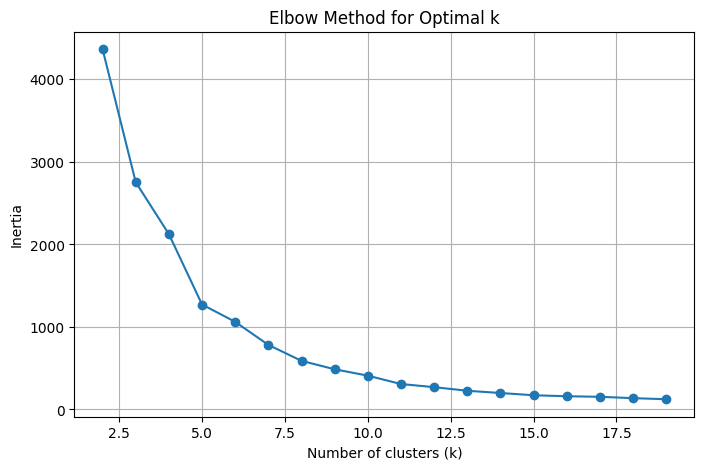

Cluster centroids:
        max PGMV        lat       long
0   28309.147117  25.313816  82.991523
1    2734.445000  -0.171669   2.908641
2  204463.626364  25.399076  81.923373
3   85939.315000  25.267215  82.562402
4    7597.316667  22.768770  77.494717
5    4694.868858  25.324508  82.980878
6  530813.190000  25.318088  83.001287
7     603.390000  10.605417  79.349303
8       8.770000   8.419083  15.570111
9    5263.290000 -12.862515   3.494461


,buyer_phone,buyer_org_name,buyer_pincode,Wh name,buyer_city,shipto_city,buyer_state,Address,march_24,feb_24,...,oct_23,max PGMV,lat,long,Customer_Id with us,LOM,KYC flag with us,Cohort,cust_id,cluster
0,8318277183,M/S sakshi general store,221011,Varanasi-GTM-Wholesale,Varanasi,Varanasi,Uttar Pradesh,"Ramana,Ramana,Sant Lawrence school,Varanasi,Ut...",4146.64,2377.99,...,5941.94,6080.03,25.243084,83.011872,NaN,NaT,NaN,app not installed,1,5
1,9793326226,Jayswal genERAL store,221101,Varanasi-GTM-Wholesale,Varanasi,Varanasi,Uttar Pradesh,"Belwababa market Lamhi,Belwa baba market lamhi...",15697.32,4728.43,...,10833.88,15697.32,25.380540,82.987205,NaN,NaT,NaN,app not installed,2,5
2,9532680217,Indrasani store,221003,Varanasi-GTM-Wholesale,Varanasi,Varanasi,Uttar Pradesh,"S/3512,Shivpur market,In front swastik gardeni...",0.00,2349.08,...,0.00,2349.08,25.354570,82.962619,NaN,NaT,NaN,app not installed,3,5
3,9838177432,Dablu kirana store,221101,Varanasi-GTM-Wholesale,Varanasi,Varanasi,Uttar Pradesh,"Niyar dih market vns,Niyardih market vns,Chole...",3550.87,3495.38,...,330.08,4607.30,25.531072,83.053856,NaN,NaT,NaN,app not installed,4,5
4,8173996024,ANISH AHMAD S/O ASFAK AHMAD,232101,Varanasi-GTM-Wholesale,Varanasi,Varanasi,Uttar Pradesh,"Dulhipur,Bhisauri,Karbla road ,Varanasi,Uttar ...",1047.36,113.49,...,2699.76,2699.76,25.307605,83.084217,NaN,NaT,NaN,app not installed,5,5


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_excel(r"C:\Users\owner55\Downloads\VRN-Onboarding data w Satyam.xlsx")

# -------------------------
# 1. Add cust_id
# -------------------------
df['cust_id'] = range(1, len(df) + 1)

# -------------------------
# 2. Prepare features
# -------------------------
df = df.dropna(how='any', subset=['max PGMV', 'lat', 'long'])
df = df.reset_index(drop=True)
features = df[['max PGMV', 'lat', 'long']].copy()
# features = features.dropna(how='any')

# Handle missing values
# features = features.fillna(features.median())

# -------------------------
# 3. Scale features
# -------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# -------------------------
# 4. Elbow Method to choose k
# -------------------------
inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# -------------------------
# 5. Choose k manually after eyeballing elbow
# Example: Let's assume k = 4
# -------------------------
optimal_k = 10  # <-- change this based on elbow graph

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(scaled_features)

# -------------------------
# 6. Get cluster centroids (optional)
# -------------------------
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_), 
    columns=['max PGMV', 'lat', 'long']
)

print("Cluster centroids:")
print(centroids)

# Final dataframe with cluster assigned
df.head()


In [25]:
df.to_excel("clustered_output.xlsx", index=False)